# MALL CUSTOMER DETAILS

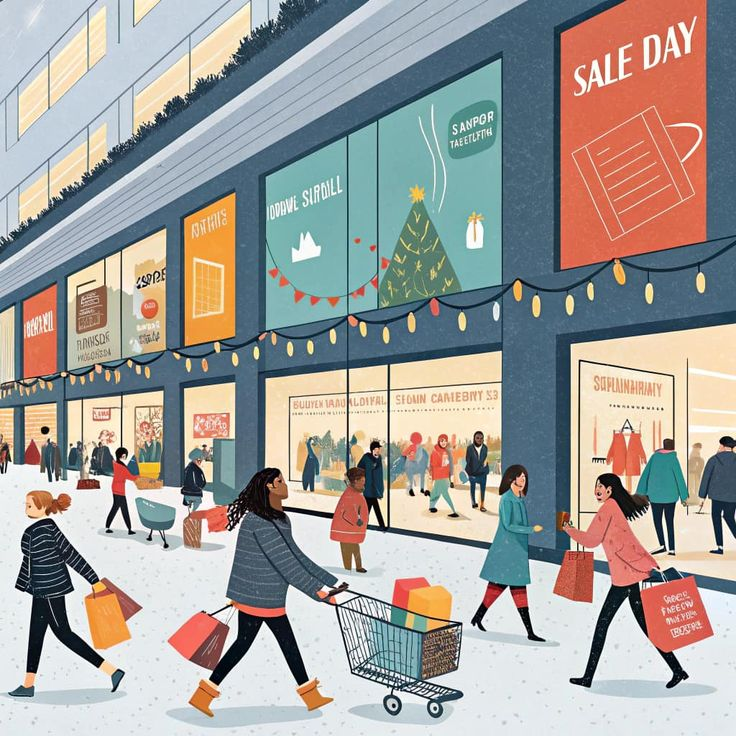

# OBJECTIVES

*To segment mall customers into distinct groups based on their age, annual income, and spending score using K-Means Clustering, helping businesses understand customer behavior and develop targeted marketing strategies.*

# DATASET OVERVIEW
*The Mall Customers dataset contains information about 200 customers and their demographic and spending behavior. It is used to understand customer patterns and segment customers into different groups using K-Means Clustering.*

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv(r'/content/Mall_Customers.csv')

In [ ]:
df.head(201)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.shape

(200, 5)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Age *Distribution*

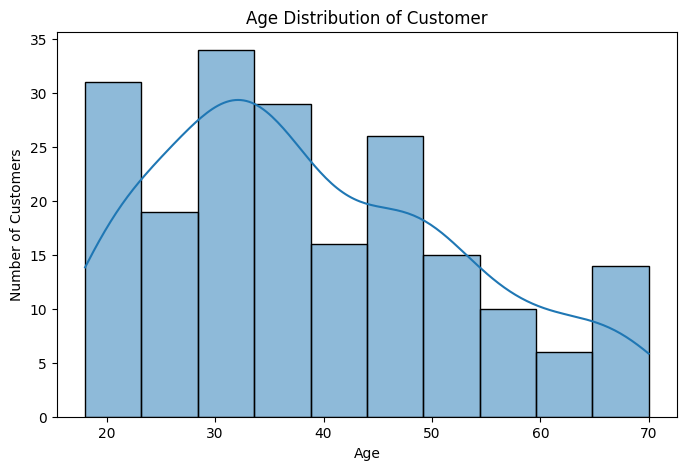

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title('Age Distribution of Customer')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

# Gender *Distribution*

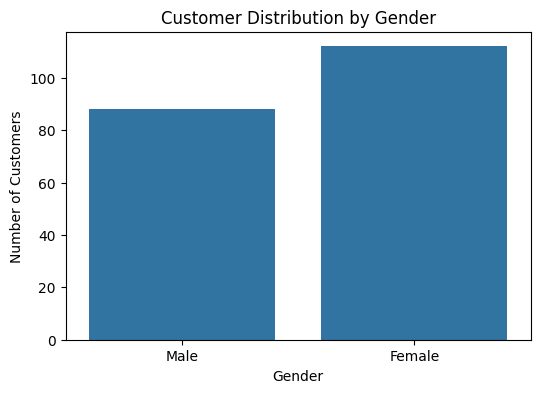

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', data=df)

plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.show()

# *Annual Income Distribution*

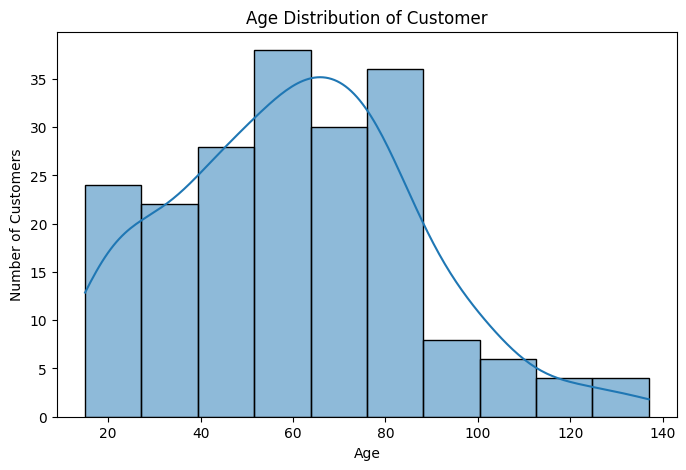

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=10, kde=True)

plt.title('Age Distribution of Customer')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

# *Relationship between Income and Spending Score*

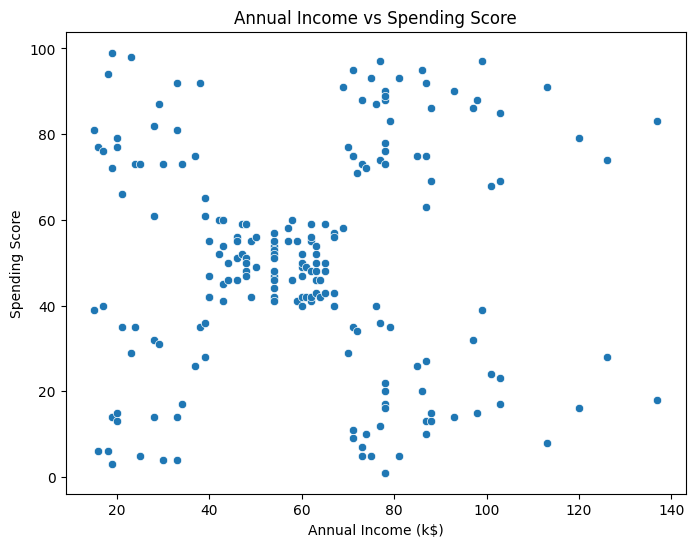

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')

plt.show()

In [ ]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


# *Elbow Method*

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

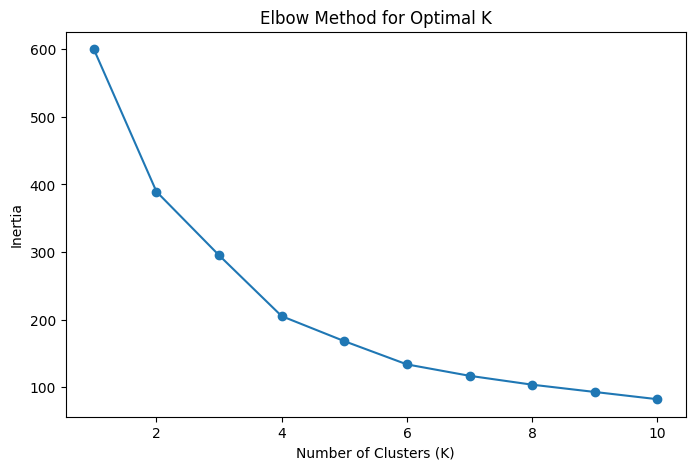

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), inertia, marker='o')

plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

# Adding Cluster *Labels*

In [ ]:
df['Cluster'] = kmeans.labels_

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


# *Customers in Each Cluster*

In [ ]:
df['Cluster'].value_counts().sort_index()

,count
Cluster,
0,65
1,40
2,57
3,38


# *Visualizing the Clusters*

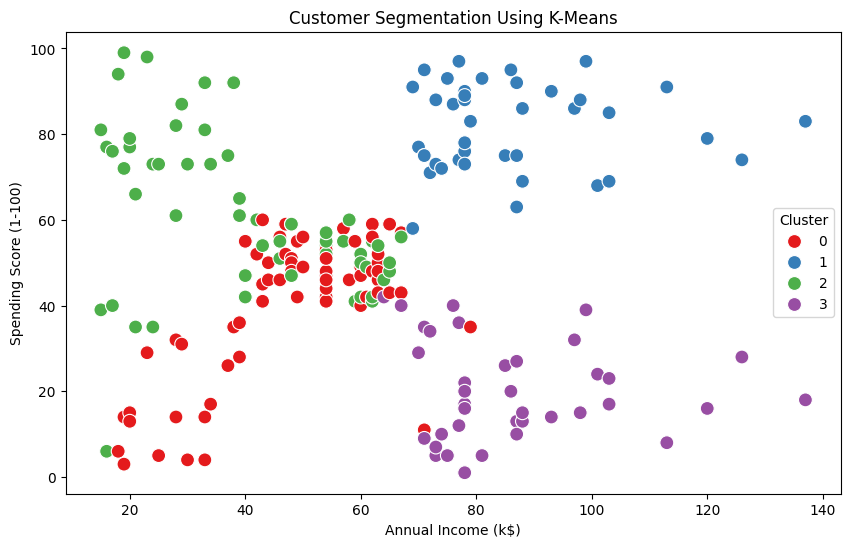

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100
)

plt.title('Customer Segmentation Using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.show()

In [ ]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

cluster_summary

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,53.984615,47.707692,39.969231
1,32.875000,86.100000,81.525000
2,25.438596,40.000000,60.298246
3,39.368421,86.500000,19.578947


# *Train Model*

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X_scaled)

KMeans(n_clusters=4, n_init=10, random_state=42)

# *Adding Label*

In [ ]:
df['Cluster'] = kmeans.labels_

# *Cluster Summary*

In [ ]:
cluster_summary = df.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean()

cluster_summary['Interpretation'] = [
    'Mature, moderate-income, moderate-spending customers',
    'High-income, high-spending customers',
    'Young, lower-income, high-spending customers',
    'High-income, low-spending customers'
]

cluster_summary



,Age,Annual Income (k$),Spending Score (1-100),Interpretation
Cluster,,,,
0,53.984615,47.707692,39.969231,"Mature, moderate-income, moderate-spending cus..."
1,32.875000,86.100000,81.525000,"High-income, high-spending customers"
2,25.438596,40.000000,60.298246,"Young, lower-income, high-spending customers"
3,39.368421,86.500000,19.578947,"High-income, low-spending customers"


# *Cutomer Segmentation plot*

In [ ]:
# Get cluster centers and convert them back to original scale
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers_df = pd.DataFrame(
    centers,
    columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
)

# Add cluster numbers
centers_df['Cluster'] = range(4)

# Add cluster names
cluster_names = {
    0: 'Mature Moderate Spenders',
    1: 'Premium High Spenders',
    2: 'Young High Spenders',
    3: 'High-Income Low Spenders'
}

centers_df['Cluster Name'] = centers_df['Cluster'].map(cluster_names)

centers_df

,Age,Annual Income (k$),Spending Score (1-100),Cluster,Cluster Name
0,53.984615,47.707692,39.969231,0,Mature Moderate Spenders
1,32.875000,86.100000,81.525000,1,Premium High Spenders
2,25.438596,40.000000,60.298246,2,Young High Spenders
3,39.368421,86.500000,19.578947,3,High-Income Low Spenders


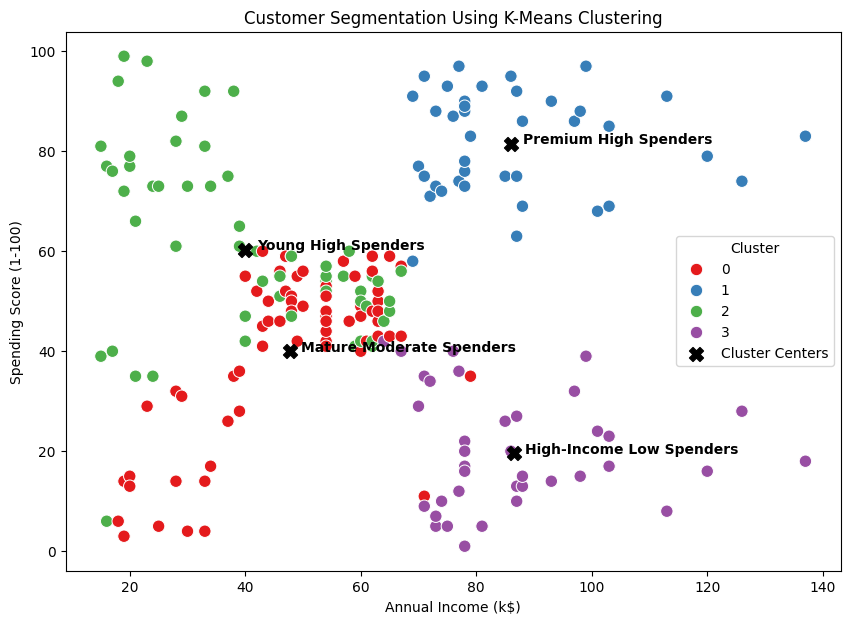

In [ ]:
plt.figure(figsize=(10, 7))

# Customer points
sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=80
)

# Cluster centers
plt.scatter(
    centers_df['Annual Income (k$)'],
    centers_df['Spending Score (1-100)'],
    marker='X',
    s=100,
    color='black',
    label='Cluster Centers'
)

# Add cluster names to centers
for _, row in centers_df.iterrows():
    plt.text(
        row['Annual Income (k$)'] + 2,
        row['Spending Score (1-100)'],
        row['Cluster Name'],
        fontsize=10,
        fontweight='bold'
    )

plt.title('Customer Segmentation Using K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')
plt.show()